## Create Model and Run

In [3]:
import sys
sys.path.append('..')
from datasets import load_dataset
from python_scripts import FlowExperiment, FlowModelConfig, Interpolant, prime_dataset, get_size_and_channel
import torch

# load the dataset
dataset_target = load_dataset("natejuw/cats-faces-64x64-tensor")

# get the image size and channel amount (should be 1 channel for grayscale and 3 channels for RGB)
# we assume that the input dataset has square images
IMAGE_SIZE, CHANNELS = get_size_and_channel(dataset_target)

# unet keeps images as (C, H, W), no flattening
dataset_target = prime_dataset(dataset_target, model_type='unet', img_size=IMAGE_SIZE)

# configure the model
cfg = FlowModelConfig(
    model_type   = 'unet',
    img_size     = IMAGE_SIZE,
    channels     = CHANNELS,
    unet_variant = 'unet_small',
)

# choose interpolant
interp = Interpolant('linear')

# create experiment
exp = FlowExperiment(cfg, interp, stepping='ode')

# train
history = exp.train(
    dataset_base   = dataset_target,
    dataset_target = dataset_target,
    n_iterations   = 2000,
    batch_size     = 32,
    base_lr        = 1e-3,
    log_every      = 200,
    rand_run       = True,
    out_name       = 'cat_faces_unet_small',
)

Using device: cuda
── Training velocity model ──
initial | obj 0.0925 | mse 1.4454 | pred_mean -0.2231 | pred_std 0.3436


Training velocity: 100%|██████████| 2000/2000 [04:32<00:00,  7.35it/s, obj=-0.4965, mse=0.2316, grad=0.113, memory=1.44 GB / 11.90 GB (12.12%)]

Saved to cat_faces_unet_small_velocity.pt


## Plot Loss and Visualise Flow

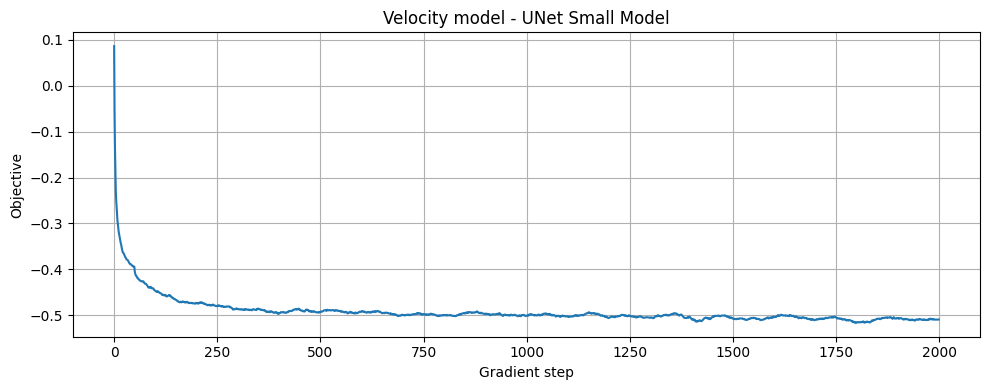

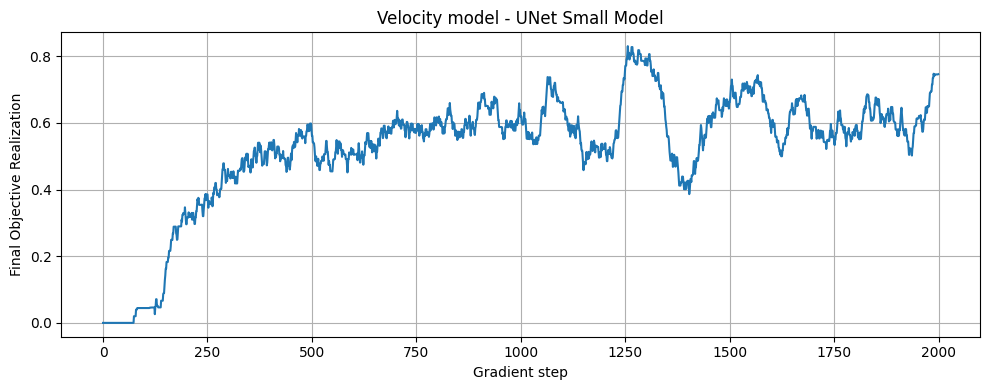

/tmp/ipykernel_3851059/2778553233.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample   = torch.tensor(dataset_target['train']['pixel_values'][0])


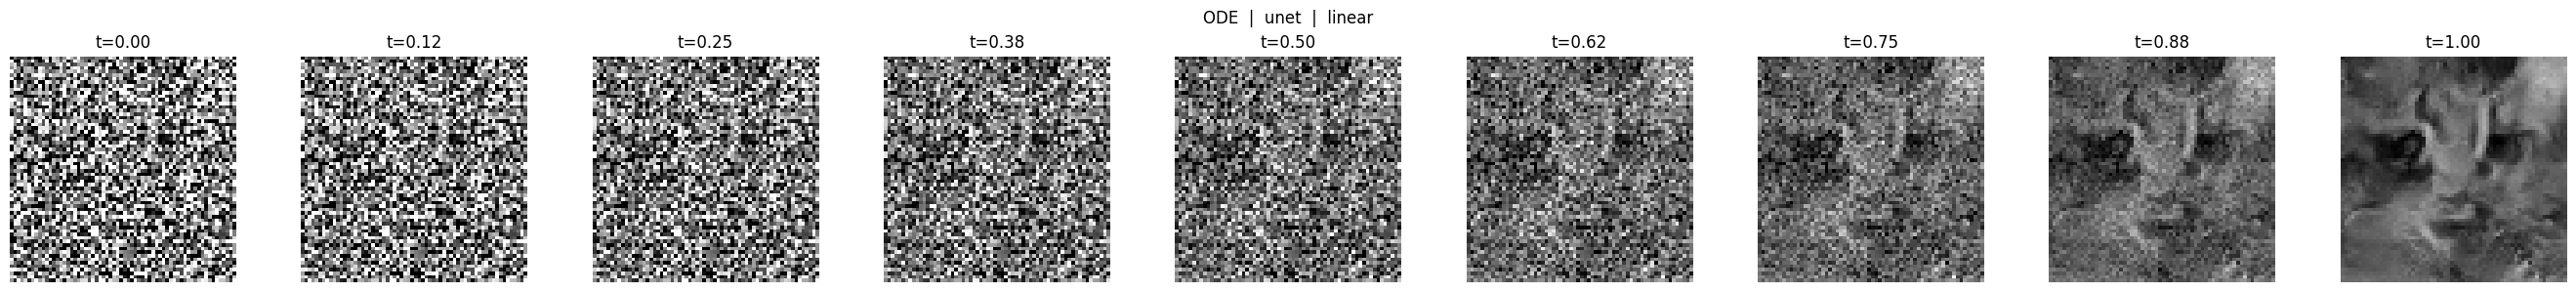

In [5]:
from python_scripts import plot_loss, get_percent_plot
from datasets import Dataset, DatasetDict

# plot the loss curve
plot_loss(history['velocity_loss'], title='Velocity model - UNet Small Model')
get_percent_plot(history['velocity_loss'], title='Velocity model - UNet Small Model')
sample   = torch.tensor(dataset_target['train']['pixel_values'][0])
gaussian = torch.randn_like(sample)
dataset_base = DatasetDict({"train": Dataset.from_dict({"pixel_values": [gaussian.numpy()]})})

exp.visualise(
    dataset_base     = dataset_base,
    n_steps          = 1000,
    save_frames      = 9,
    use_random_start = True,
)

## FID

We have been working with the MNIST dataset with 10,000 samples from it and as of now we have used the UNET which produces significantly nicer results than an MLP. We have been working under the most optimal settings, with a linear transport and a $\gamma(t)=0$. Now we want to evaluate the FID of the UNET.

In [7]:
import torch
import importlib
import python_scripts.utils as utils_module
import python_scripts.experiment as exp_module

# Save model weights
torch.save(exp.model_velocity.state_dict(), 'temp_weights.pt')

# Reload modules
importlib.reload(utils_module)
importlib.reload(exp_module)
from python_scripts.experiment import FlowExperiment

# Recreate exp and restore weights
exp = FlowExperiment(cfg, interp, stepping='ode')
exp.model_velocity.load_state_dict(torch.load('temp_weights.pt'))

# Now run FID
fid_unet_small = exp.fid(dataset_target, steps=200, batch_size=64)
print(fid_unet_small)

Using device: cuda


/tmp/ipykernel_1703742/3722641904.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  exp.model_velocity.load_state_dict(torch.load('temp_weights.pt'))
Flowing dataset: 100

Flowing done. Removed 0 samples due to blowup.


Filtering: 100%|██████████| 10000/10000 [00:00<00:00, 119607.61it/s]


Kept 10000/10000 samples  (threshold=0.9)
41.30064538315002
